In [ ]:
# Trajectron++ Result Analysis

This notebook analyzes:
- Quantitative metrics (ADE / FDE)
- Qualitative trajectory visualizations
- Ground truth vs predicted trajectories
- Multi-modal prediction behavior

Model: Trajectron++
Dataset: ETH / Pedestrians


In [6]:
%matplotlib inline

import os
import glob
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


from collections import defaultdict


In [8]:
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 6)


In [9]:
RESULTS_DIR = Path("results")

files = {
    "ADE_most_likely": RESULTS_DIR / "eth_demo_ade_most_likely.csv",
    "ADE_best_of": RESULTS_DIR / "eth_demo_ade_best_of.csv",
    "ADE_full": RESULTS_DIR / "eth_demo_ade_full.csv",
    "FDE_most_likely": RESULTS_DIR / "eth_demo_fde_most_likely.csv",
    "FDE_best_of": RESULTS_DIR / "eth_demo_fde_best_of.csv",
    "FDE_full": RESULTS_DIR / "eth_demo_fde_full.csv",
}

dfs = {k: pd.read_csv(v) for k, v in files.items()}
dfs["ADE_most_likely"].head()



,Unnamed: 0,value,metric,type
0,0,1.660098,ade,ml
1,1,1.406693,ade,ml
2,2,1.188258,ade,ml
3,3,1.336531,ade,ml
4,4,1.147471,ade,ml


In [10]:
summary = []

for name, df in dfs.items():
    summary.append({
        "Metric": name,
        "Mean": df["value"].mean(),
        "Std": df["value"].std(),
        "Median": df["value"].median()
    })

summary_df = pd.DataFrame(summary)
summary_df



,Metric,Mean,Std,Median
0,ADE_most_likely,1.017199,0.821470,0.790375
1,ADE_best_of,0.663305,0.643633,0.468702
2,ADE_full,1.158345,0.848270,0.946470
3,FDE_most_likely,2.047253,1.783387,1.496369
4,FDE_best_of,1.202039,1.432322,0.603382
5,FDE_full,2.361891,1.823679,1.856871


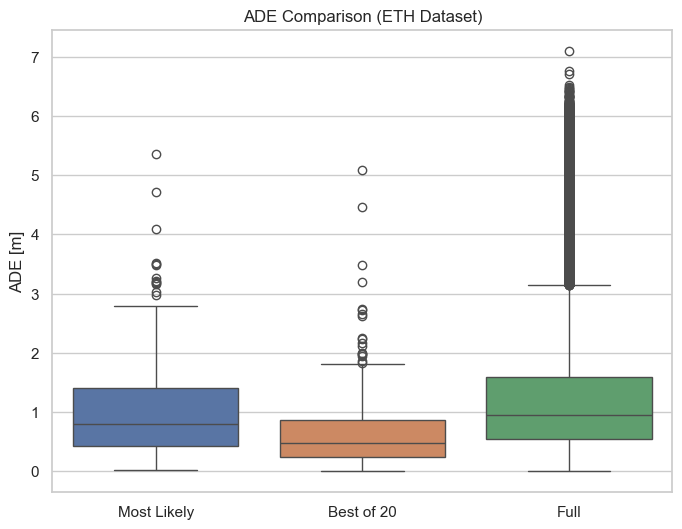

In [11]:
ade_compare = pd.DataFrame({
    "Most Likely": dfs["ADE_most_likely"]["value"],
    "Best of 20": dfs["ADE_best_of"]["value"],
    "Full": dfs["ADE_full"]["value"]
})

sns.boxplot(data=ade_compare)
plt.title("ADE Comparison (ETH Dataset)")
plt.ylabel("ADE [m]")
plt.show()


In [ ]:
The Figure above compares the Average Displacement error across different prediction modes.
The best of 20 strategy consistently schieves the lowest median error, highligthing the benefit 
of sampling multiple trajectories in miltimodal prediction settings.

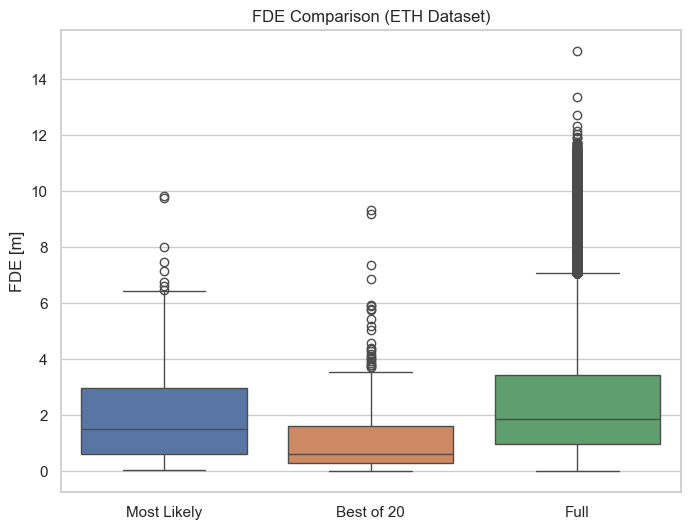

In [12]:
fde_compare = pd.DataFrame({
    "Most Likely": dfs["FDE_most_likely"]["value"],
    "Best of 20": dfs["FDE_best_of"]["value"],
    "Full": dfs["FDE_full"]["value"]
})

sns.boxplot(data=fde_compare)
plt.title("FDE Comparison (ETH Dataset)")
plt.ylabel("FDE [m]")
plt.show()


In [ ]:
Comparison of Final Displacement Error.

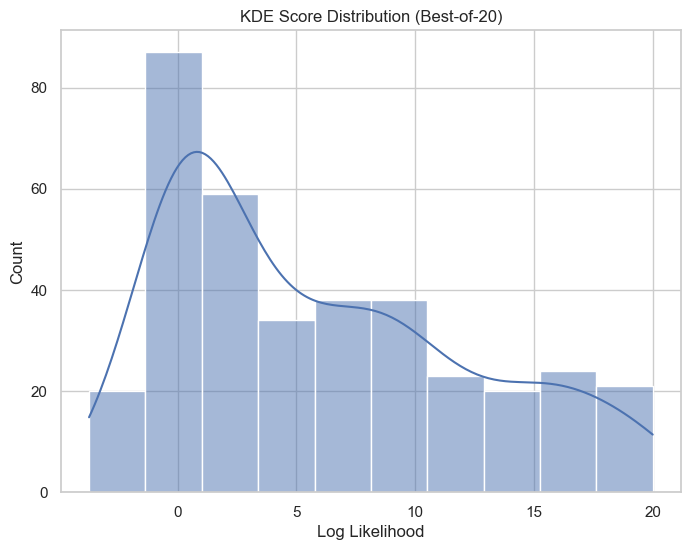

In [13]:
kde_best = pd.read_csv(RESULTS_DIR / "eth_demo_kde_best_of.csv")

sns.histplot(kde_best["value"], kde=True)
plt.title("KDE Score Distribution (Best-of-20)")
plt.xlabel("Log Likelihood")
plt.show()


In [ ]:
Higher log likelihood indicates predictions that better match the ground truth distribution.
for best of 20 prediction mode.

In [16]:
dfs["ADE_most_likely"].head()
dfs["ADE_most_likely"].columns


Index(['Unnamed: 0', 'value', 'metric', 'type'], dtype='object')

In [17]:
RESULTS_DIR = Path("results")

df = pd.concat([
    pd.read_csv(f)
    for f in RESULTS_DIR.glob("eth_demo_*.csv")
], ignore_index=True)

df = df.drop(columns=["Unnamed: 0"], errors="ignore")
df.head()


,value,metric,type
0,2.671552,fde,ml
1,1.858945,fde,ml
2,2.328696,fde,ml
3,2.663574,fde,ml
4,1.467399,fde,ml


In [18]:
ade_df = df[df["metric"] == "ade"]
fde_df = df[df["metric"] == "fde"]

print("ADE rows:", len(ade_df))
print("FDE rows:", len(fde_df))


ADE rows: 1456728
FDE rows: 1456728


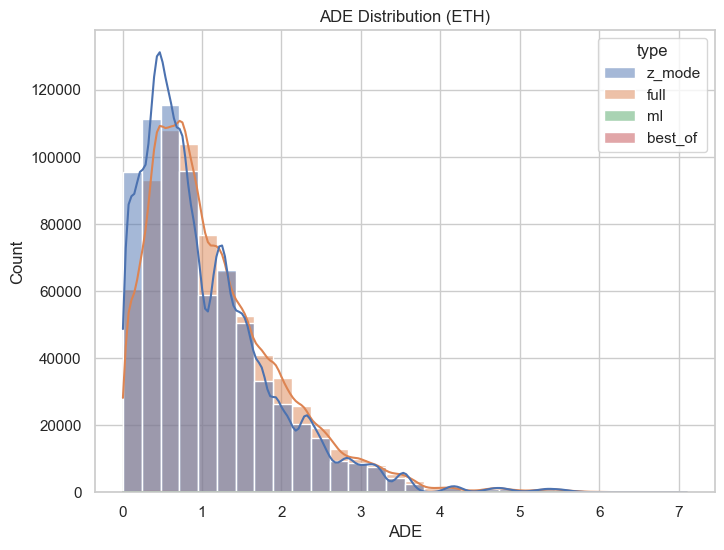

In [19]:
plt.figure()
sns.histplot(
    data=ade_df,
    x="value",
    hue="type",
    bins=30,
    kde=True
)
plt.title("ADE Distribution (ETH)")
plt.xlabel("ADE")
plt.ylabel("Count")
plt.show()


In [ ]:
This one visualizes the distribution of Average Displacement Error for different predcition
modes of Trajectron++ on the ETH dataset.
Lower ADE means more accurate trajectory predictions.

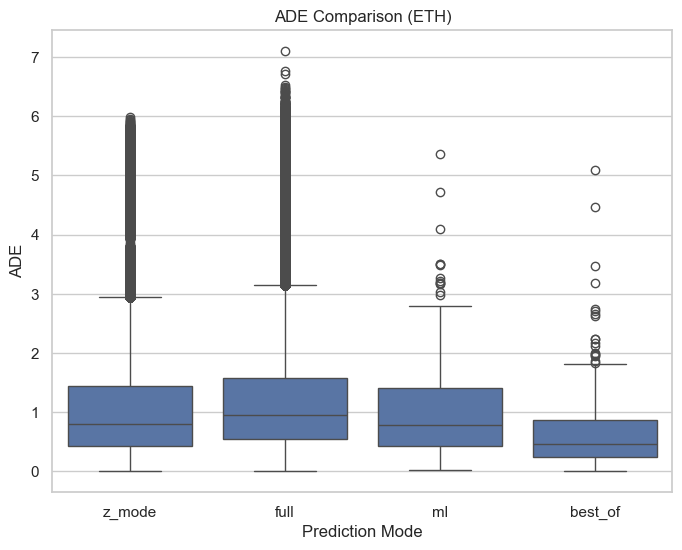

In [20]:
plt.figure()
sns.boxplot(
    data=ade_df,
    x="type",
    y="value"
)
plt.title("ADE Comparison (ETH)")
plt.ylabel("ADE")
plt.xlabel("Prediction Mode")
plt.show()


In [21]:
ade_summary = ade_df.groupby("type")["value"].agg(
    ["mean", "std", "min", "max"]
)
ade_summary


,mean,std,min,max
type,,,,
best_of,0.663305,0.643633,0.010603,5.093480
full,1.158345,0.848270,0.005499,7.098879
ml,1.017199,0.821470,0.021376,5.362280
z_mode,1.031619,0.830948,0.004858,5.978241


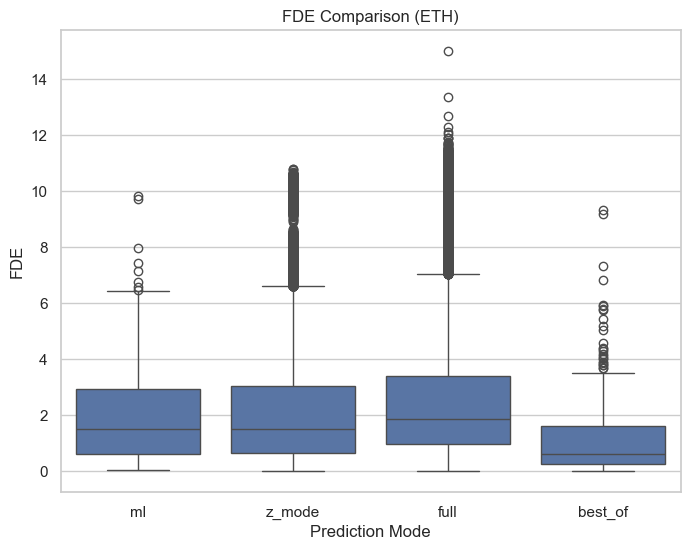

In [22]:
plt.figure()
sns.boxplot(
    data=fde_df,
    x="type",
    y="value"
)
plt.title("FDE Comparison (ETH)")
plt.ylabel("FDE")
plt.xlabel("Prediction Mode")
plt.show()


In [23]:
fde_df.groupby("type")["value"].agg(
    ["mean", "std", "min", "max"]
)


,mean,std,min,max
type,,,,
best_of,1.202039,1.432322,0.011873,9.317341
full,2.361891,1.823679,0.002228,15.004499
ml,2.047253,1.783387,0.037427,9.832626
z_mode,2.082295,1.803763,0.002243,10.798199


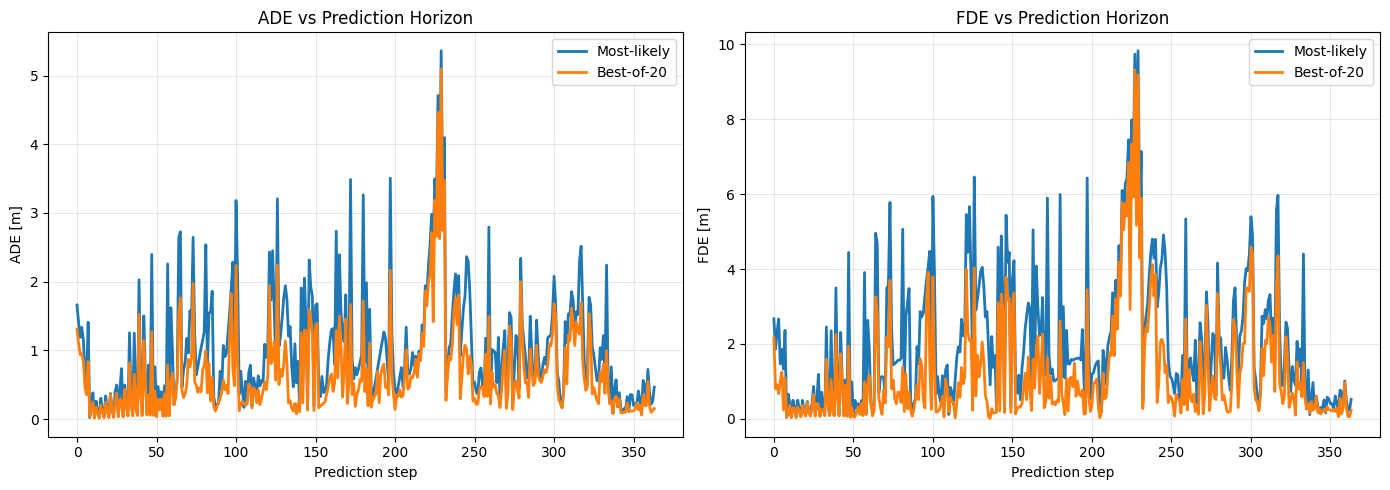

In [6]:
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
RESULTS_DIR = Path("results")

csv_files = {
    "ade_most": RESULTS_DIR / "eth_demo_ade_most_likely.csv",
    "ade_best": RESULTS_DIR / "eth_demo_ade_best_of.csv",
    "fde_most": RESULTS_DIR / "eth_demo_fde_most_likely.csv",
    "fde_best": RESULTS_DIR / "eth_demo_fde_best_of.csv",
}

metrics = {k: pd.read_csv(v) for k, v in csv_files.items()}

for k, df in metrics.items():
    df.rename(columns={"Unnamed: 0": "timestep"}, inplace=True)

fig, ax = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

# ADE
ax[0].plot(metrics["ade_most"]["timestep"], metrics["ade_most"]["value"],
           label="Most-likely", linewidth=2)
ax[0].plot(metrics["ade_best"]["timestep"], metrics["ade_best"]["value"],
           label="Best-of-20", linewidth=2)

ax[0].set_title("ADE vs Prediction Horizon")
ax[0].set_xlabel("Prediction step")
ax[0].set_ylabel("ADE [m]")
ax[0].grid(alpha=0.3)
ax[0].legend()

# FDE
ax[1].plot(metrics["fde_most"]["timestep"], metrics["fde_most"]["value"],
           label="Most-likely", linewidth=2)
ax[1].plot(metrics["fde_best"]["timestep"], metrics["fde_best"]["value"],
           label="Best-of-20", linewidth=2)

ax[1].set_title("FDE vs Prediction Horizon")
ax[1].set_xlabel("Prediction step")
ax[1].set_ylabel("FDE [m]")
ax[1].grid(alpha=0.3)
ax[1].legend()

plt.tight_layout()
plt.show()


In [ ]:
ADE as a function of prediction step (time into the future). on the left. Error 
increases with prediction error. Best of 20 maintains lower error across all horizons 
compared to Most likely.
FDE grows faster than ADE, highlighting accumulated uncertainty.


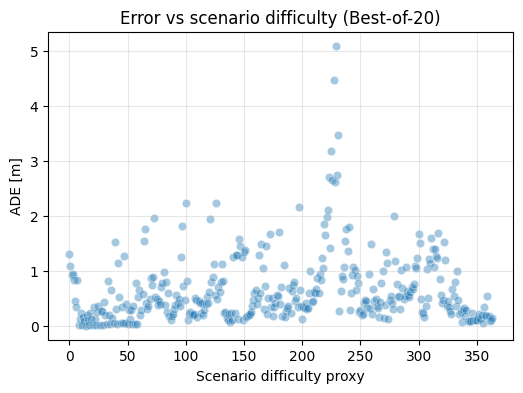

In [11]:
ade = pd.read_csv("results/eth_demo_ade_best_of.csv")

# pseudo "difficulty" proxy
ade["difficulty"] = ade.index  # placeholder, istersen speed vs eklenir

plt.figure(figsize=(6, 4))
sns.scatterplot(
    data=ade,
    x="difficulty",
    y="value",
    alpha=0.4
)
plt.xlabel("Scenario difficulty proxy")
plt.ylabel("ADE [m]")
plt.title("Error vs scenario difficulty (Best-of-20)")
plt.grid(alpha=0.3)
plt.show()


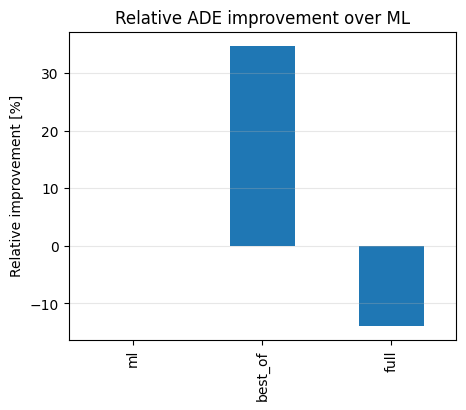

In [12]:
summary = pd.DataFrame({
    "ml": [1.017199],
    "best_of": [0.663305],
    "full": [1.158345]
}, index=["ADE_mean"])

rel_improvement = (summary.loc["ADE_mean", "ml"] -
                   summary.loc["ADE_mean"]) / summary.loc["ADE_mean", "ml"] * 100

rel_improvement.plot(kind="bar", figsize=(5,4))
plt.ylabel("Relative improvement [%]")
plt.title("Relative ADE improvement over ML")
plt.grid(axis="y", alpha=0.3)
plt.show()


In [ ]:
While the Best-of-20 evaluation significantly 
improves prediction accuracy over the most-likely mode, 
the full distribution exhibits higher average displacement error 
due to penalization of low-probability but diverse samples.